# Model Optimization and Explainability

This notebook explores feature selection, hyperparameter optimization, and model explainability to further evaluate and improve the baseline employee attrition models. The optimized models are compared against their baseline counterparts, and the final model is interpreted using SHAP before being prepared for deployment.

## 1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import optuna
import shap
import joblib

## 2. Load Dataset

In [3]:

df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")


df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Data Preprocessing
The preprocessing pipeline from Notebook 2 is reused to prepare the dataset for model optimization.

In [4]:
# Drop unnecessary columns
df = df.drop(columns=[
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
])

# Encode target variable
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True, dtype=int)

# Split features and target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Training set:", X_train_smote.shape)
print("Testing set :", X_test.shape)

Training set: (1972, 44)
Testing set : (294, 44)


In [5]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [6]:
print("Before SMOTE")
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nAfter SMOTE")
print("Training set:", X_train_smote.shape)

print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE
Training set: (1176, 44)
Testing set : (294, 44)

After SMOTE
Training set: (1972, 44)

Class distribution before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64

Class distribution after SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


## 4. Feature Selection

### 4.1 Mutual Information

In [8]:

mi_scores = mutual_info_classif(
    X_train_smote,
    y_train_smote,
    random_state=42
)


mi_df = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "MI Score": mi_scores
})


mi_df = mi_df.sort_values(
    by="MI Score",
    ascending=False
).reset_index(drop=True)

mi_df.head(10)

,Feature,MI Score
0,StockOptionLevel,0.104633
1,MonthlyIncome,0.095451
2,YearsWithCurrManager,0.091640
3,YearsAtCompany,0.085097
4,YearsInCurrentRole,0.076084
5,JobInvolvement,0.072462
6,MaritalStatus_Married,0.064384
7,JobLevel,0.060193
8,JobSatisfaction,0.057555
9,TotalWorkingYears,0.054868


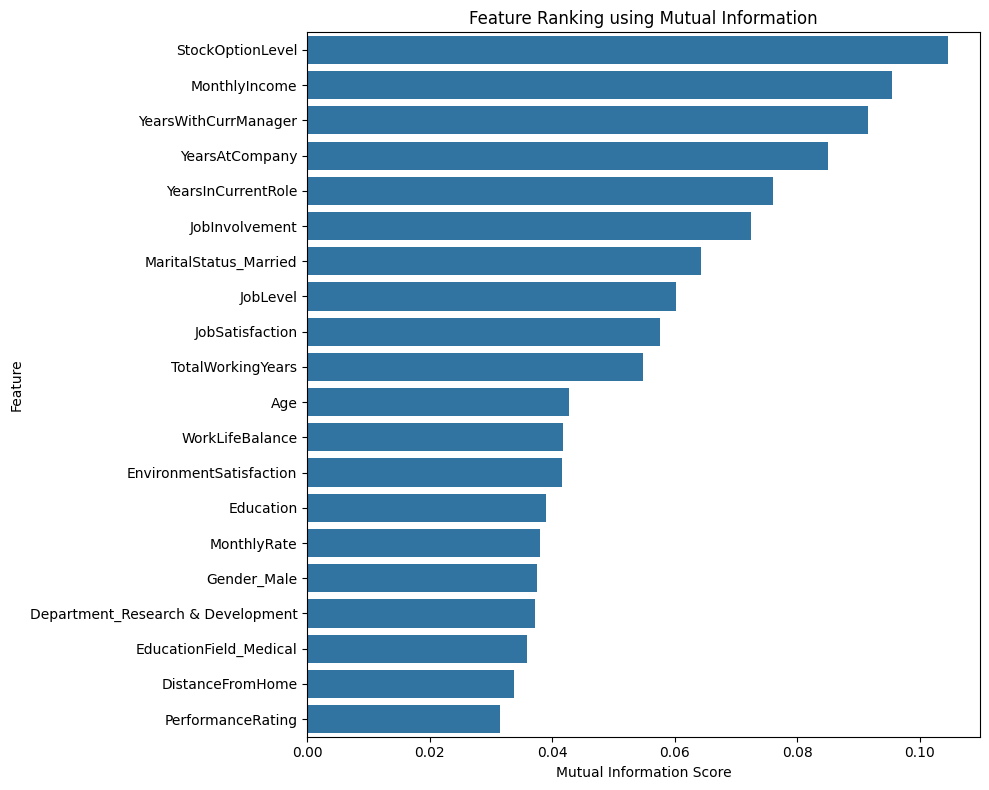

In [10]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=mi_df.head(20),
    x="MI Score",
    y="Feature"
)

plt.title("Feature Ranking using Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 4.2 Recursive Feature Elimination (RFE)


In [13]:
rfe = RFE(
    estimator=xgb.XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    n_features_to_select=20
)

rfe.fit(X_train_smote, y_train_smote)

selected_features = X_train_smote.columns[rfe.support_]

selected_features

Index(['EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'RelationshipSatisfaction', 'StockOptionLevel',
       'WorkLifeBalance', 'YearsWithCurrManager',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Human Resources',
       'JobRole_Research Scientist', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'OverTime_Yes'],
      dtype='object')

In [14]:
rfe_df = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "Selected": rfe.support_
})

rfe_selected = rfe_df[rfe_df["Selected"]].reset_index(drop=True)

rfe_selected

,Feature,Selected
0,EnvironmentSatisfaction,True
1,JobInvolvement,True
2,JobLevel,True
3,JobSatisfaction,True
4,RelationshipSatisfaction,True
5,StockOptionLevel,True
6,WorkLifeBalance,True
7,YearsWithCurrManager,True
8,Department_Research & Development,True
9,Department_Sales,True


In [15]:
X_train_rfe = X_train_smote[selected_features]
X_test_rfe = X_test[selected_features]

print(X_train_rfe.shape)
print(X_test_rfe.shape)

(1972, 20)
(294, 20)


In [16]:
gb_rfe = GradientBoostingClassifier(random_state=42)
gb_rfe.fit(X_train_rfe, y_train_smote)

xgb_rfe = xgb.XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb_rfe.fit(X_train_rfe, y_train_smote)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [17]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [18]:
gb_rfe_results = evaluate_model(
    gb_rfe,
    X_test_rfe,
    y_test
)

xgb_rfe_results = evaluate_model(
    xgb_rfe,
    X_test_rfe,
    y_test
)

comparison_rfe = pd.DataFrame(
    [gb_rfe_results, xgb_rfe_results],
    index=["Gradient Boosting", "XGBoost"]
)

comparison_rfe

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Gradient Boosting,0.840136,0.500000,0.425532,0.459770,0.772849
XGBoost,0.829932,0.459459,0.361702,0.404762,0.788440





Mutual Information was used to rank feature importance, while RFE was evaluated as a feature selection technique. Although RFE reduced the feature set from 44 to 20 features, it did not provide a meaningful improvement in model performance. Therefore, all features were retained for subsequent hyperparameter optimization.

## 5. Hyperparameter Optimization

### 5.1 Gradient Boosting

In [21]:
from sklearn.model_selection import cross_val_score

In [22]:
def objective_gb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "random_state": 42
    }

    model = GradientBoostingClassifier(**params)

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=5,
        scoring="f1"
    ).mean()

    return score

In [23]:
study_gb = optuna.create_study(direction="maximize")

study_gb.optimize(
    objective_gb,
    n_trials=30
)

[I 2026-07-27 23:53:40,459] A new study created in memory with name: no-name-79d161c5-2040-4a9e-a5fc-9da7c0d742a3
[I 2026-07-27 23:53:49,931] Trial 0 finished with value: 0.8508697488168911 and parameters: {'n_estimators': 288, 'learning_rate': 0.06667241526593173, 'max_depth': 4, 'subsample': 0.8765961901413318, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.8508697488168911.
[I 2026-07-27 23:53:51,087] Trial 1 finished with value: 0.8337361469933905 and parameters: {'n_estimators': 60, 'learning_rate': 0.16002903131040921, 'max_depth': 2, 'subsample': 0.9381809340102708, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8508697488168911.
[I 2026-07-27 23:53:56,049] Trial 2 finished with value: 0.8528755596939209 and parameters: {'n_estimators': 185, 'learning_rate': 0.20813378535558583, 'max_depth': 4, 'subsample': 0.712619938845724, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 2 with value: 0.85287555969392

In [24]:
study_gb.best_params

{'n_estimators': 244,
 'learning_rate': 0.0835106208352984,
 'max_depth': 6,
 'subsample': 0.6506095598151214,
 'min_samples_split': 2,
 'min_samples_leaf': 4}

In [25]:
best_gb = GradientBoostingClassifier(
    **study_gb.best_params,
    random_state=42
)

best_gb.fit(X_train_smote, y_train_smote)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.0835106208352984
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",244
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.6506095598151214
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",6
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in th

In [26]:
y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

gb_results = {
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb),
    "Recall": recall_score(y_test, y_pred_gb),
    "F1 Score": f1_score(y_test, y_pred_gb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_gb)
}

pd.DataFrame(gb_results, index=["Gradient Boosting (Tuned)"]).round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Gradient Boosting (Tuned),0.8503,0.56,0.2979,0.3889,0.7483


### 5.2 XGBoost


In [27]:
def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "eval_metric": "logloss"
    }

    model = xgb.XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=5,
        scoring="f1"
    ).mean()

    return score

In [28]:
study_xgb = optuna.create_study(direction="maximize")

study_xgb.optimize(
    objective_xgb,
    n_trials=30
)

[I 2026-07-28 00:06:47,930] A new study created in memory with name: no-name-d1969eaf-0e0c-471c-ae01-740eeb9de541
[I 2026-07-28 00:06:48,606] Trial 0 finished with value: 0.8500203575584054 and parameters: {'n_estimators': 96, 'max_depth': 6, 'learning_rate': 0.21198079911968185, 'subsample': 0.6228517088006336, 'colsample_bytree': 0.9719856595705624, 'gamma': 2.468159620635244, 'min_child_weight': 9, 'reg_alpha': 3.746109778988722, 'reg_lambda': 1.0650417681663509}. Best is trial 0 with value: 0.8500203575584054.
[I 2026-07-28 00:06:49,202] Trial 1 finished with value: 0.8522063241151431 and parameters: {'n_estimators': 157, 'max_depth': 8, 'learning_rate': 0.09926783911708305, 'subsample': 0.7631997756321015, 'colsample_bytree': 0.6655993310746193, 'gamma': 4.246162959396406, 'min_child_weight': 8, 'reg_alpha': 0.9665730598875177, 'reg_lambda': 2.629177587368716}. Best is trial 1 with value: 0.8522063241151431.
[I 2026-07-28 00:06:49,744] Trial 2 finished with value: 0.85451487634405

In [29]:
study_xgb.best_params

{'n_estimators': 87,
 'max_depth': 5,
 'learning_rate': 0.14246080451931728,
 'subsample': 0.6725028946898671,
 'colsample_bytree': 0.7183301247974677,
 'gamma': 1.3620684736339874,
 'min_child_weight': 6,
 'reg_alpha': 0.6339638060286933,
 'reg_lambda': 3.183739490467259}

In [30]:
best_xgb = xgb.XGBClassifier(
    **study_xgb.best_params,
    random_state=42,
    eval_metric="logloss"
)

best_xgb.fit(X_train_smote, y_train_smote)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7183301247974677
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

In [31]:
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

xgb_results = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
}

pd.DataFrame(
    xgb_results,
    index=["XGBoost (Tuned)"]
).round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
XGBoost (Tuned),0.8333,0.4706,0.3404,0.3951,0.7751


## 6. Model Comparison

In [32]:
comparison_df = pd.DataFrame({
    "Model": [
        "Gradient Boosting (Baseline)",
        "Gradient Boosting (Tuned)",
        "XGBoost (Baseline)",
        "XGBoost (Tuned)"
    ],
    "Accuracy": [0.8503, 0.8503, 0.8571, 0.8333],
    "Precision": [0.5429, 0.5600, 0.6000, 0.4706],
    "Recall": [0.4043, 0.2979, 0.3191, 0.3404],
    "F1 Score": [0.4634, 0.3889, 0.4167, 0.3951],
    "ROC-AUC": [0.7665, 0.7483, 0.7367, 0.7751]
})

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting (Baseline),0.8503,0.5429,0.4043,0.4634,0.7665
1,Gradient Boosting (Tuned),0.8503,0.5600,0.2979,0.3889,0.7483
2,XGBoost (Baseline),0.8571,0.6000,0.3191,0.4167,0.7367
3,XGBoost (Tuned),0.8333,0.4706,0.3404,0.3951,0.7751


## 7. Model Explainability



In [7]:
explainer = shap.Explainer(gb_model)
shap_values = explainer(X_test)

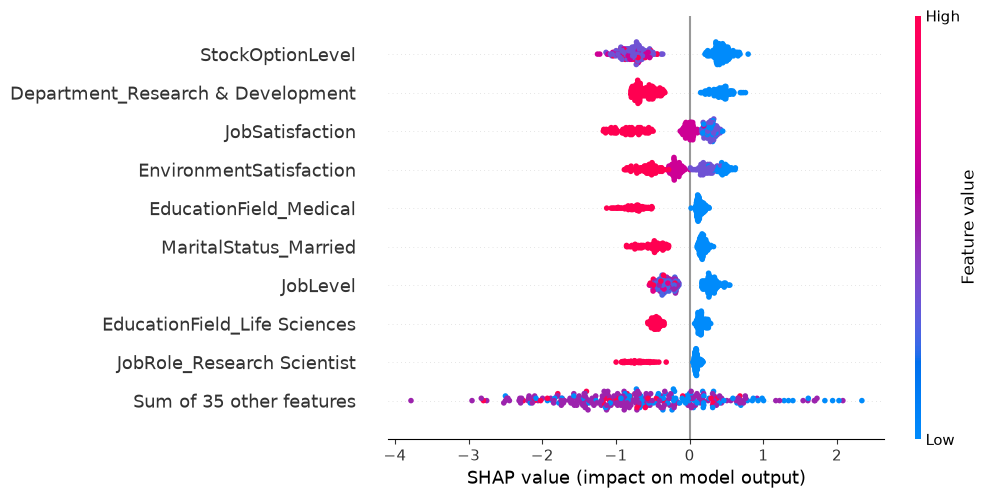

In [8]:
shap.plots.beeswarm(shap_values)

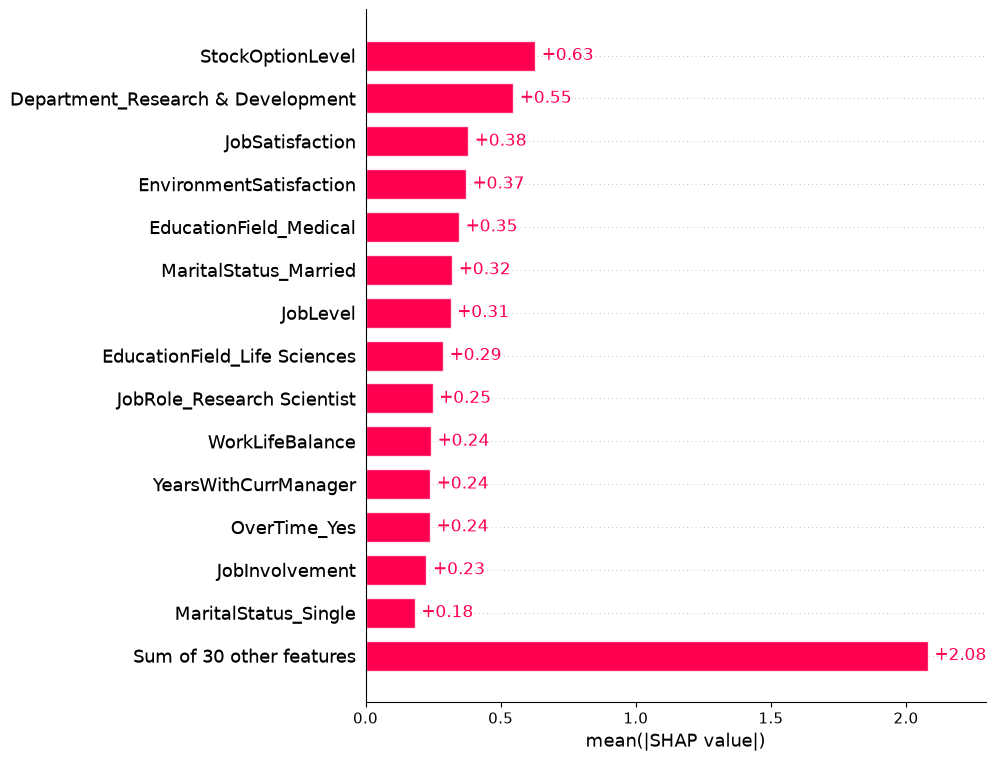

In [9]:
shap.plots.bar(
    shap_values,
    max_display=15
)

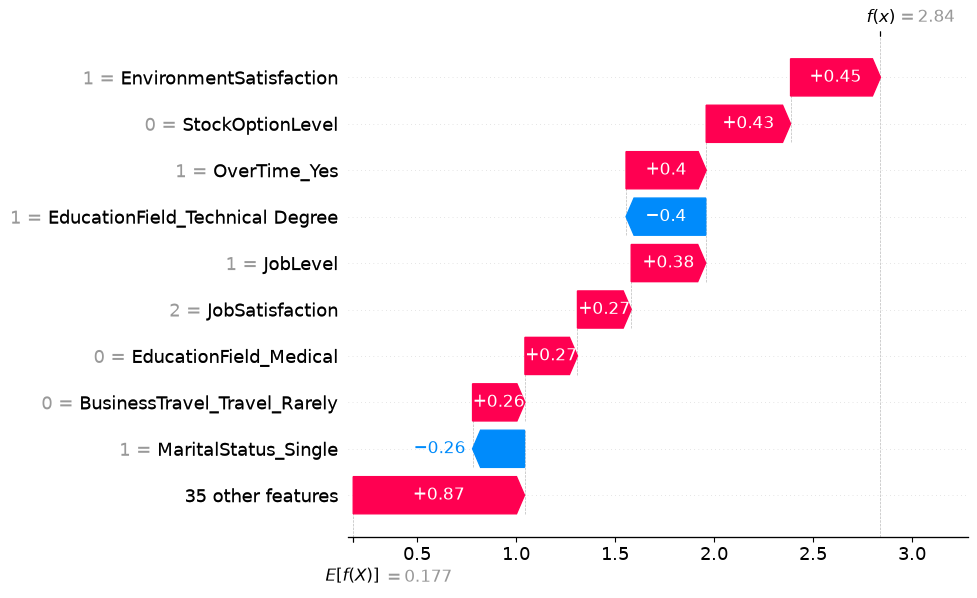

In [10]:
employee_index = np.argmax(gb_model.predict_proba(X_test)[:, 1])

shap.plots.waterfall(shap_values[employee_index])

## 8. Save Final Model



In [11]:
import joblib

In [12]:
joblib.dump(gb_model, "../models/gradient_boosting_model.pkl")
joblib.dump(list(X.columns), "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

In [13]:
print("Model and feature list saved successfully.")

Model and feature list saved successfully.


## Conclusion

- **Feature Selection:** Mutual Information and Recursive Feature Elimination (RFE) were explored to identify the most informative features. Although RFE reduced the feature set, it did not improve model performance, so all features were retained.

- **Hyperparameter Optimization:** Optuna was used to tune the Gradient Boosting and XGBoost models. While the tuned models achieved better cross-validation scores, they did not outperform the baseline models on the unseen test dataset. Therefore, the baseline Gradient Boosting model was selected as the final model.

- **Model Explainability:** SHAP was used to interpret the final model by providing both global feature importance and employee-level explanations, making the predictions transparent and easier to interpret.

- **Model Saving:** The final Gradient Boosting model and feature list were saved for deployment in the Streamlit application.